# Crypto Type Classification Analysis

This notebook provides descriptive statistics, visualizations, and classification modeling for the dataset, with 'crypto_type' as the target variable. Multiple classification algorithms are compared using pipelines and stratified train-validation splitting.

## 1. Import Required Libraries
Import pandas, numpy, matplotlib, seaborn, scikit-learn modules, and additional libraries for memory and timing measurements.

In [12]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
import time
import tracemalloc

## 2. Load and Inspect Dataset
Load the dataset into a pandas DataFrame and display its shape, columns, and a sample of rows.

In [13]:
# Load and Inspect Dataset
df = pd.read_csv('crypto_detection_research_dataset.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (25000, 52)
Columns: ['text', 'contains_crypto', 'crypto_type', 'address_found', 'confidence_label', 'text_length', 'word_count', 'sentence_count', 'avg_word_length', 'char_diversity', 'digit_ratio', 'uppercase_ratio', 'lowercase_ratio', 'special_char_ratio', 'bitcoin_legacy_count', 'bitcoin_legacy_present', 'bitcoin_segwit_count', 'bitcoin_segwit_present', 'ethereum_count', 'ethereum_present', 'litecoin_count', 'litecoin_present', 'monero_count', 'monero_present', 'dogecoin_count', 'dogecoin_present', 'ripple_count', 'ripple_present', 'cardano_count', 'cardano_present', 'total_crypto_patterns', 'multiple_addresses', 'hex_long_sequences', 'hex_medium_sequences', 'alphanumeric_long', 'alphanumeric_medium', 'crypto_keyword_count', 'crypto_keyword_density', 'has_urgent_words', 'has_security_words', 'has_order_words', 'word_length_variance', 'long_words_ratio', 'dot_count', 'comma_count', 'colon_count', 'hash_count', 'at_count', 'dataset_version', 'generation_method', 'research_purp

,text,contains_crypto,crypto_type,address_found,confidence_label,text_length,word_count,sentence_count,avg_word_length,char_diversity,...,long_words_ratio,dot_count,comma_count,colon_count,hash_count,at_count,dataset_version,generation_method,research_purpose,ethical_compliance
0,Layer 2 scaling solutions improving transactio...,0,none,NaN,high,58,7,1,7.428571,0.344828,...,0.142857,0,0,0,0,0,1.0,synthetic,crypto_address_detection,synthetic_data_only
1,Check out this new cryptocurrency project at w...,0,none,NaN,high,94,12,2,6.916667,0.255319,...,0.166667,1,0,0,0,0,1.0,synthetic,crypto_address_detection,synthetic_data_only
2,Proof of stake consensus mechanisms offer ener...,0,none,NaN,high,59,8,1,6.500000,0.305085,...,0.000000,0,0,0,0,0,1.0,synthetic,crypto_address_detection,synthetic_data_only
3,Blockchain adoption increasing among major fin...,0,none,NaN,high,65,7,1,8.428571,0.323077,...,0.142857,0,0,0,0,0,1.0,synthetic,crypto_address_detection,synthetic_data_only
4,Send payment to wallet 3whLshuJQ7CgPzDxD9HNrNx...,1,bitcoin_legacy,3whLshuJQ7CgPzDxD9HNrNx9kS5e6kT,high,94,10,1,8.500000,0.478723,...,0.200000,1,0,0,1,0,1.0,synthetic,crypto_address_detection,synthetic_data_only


## 3. Compute Descriptive Statistics
Compute summary statistics for numerical columns and value counts for categorical columns.

In [14]:
# Descriptive Statistics
print('Numerical Features Summary:')
display(df.describe())

print('\nCategorical Features Value Counts:')
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f'\n{col} value counts:')
    print(df[col].value_counts())

Numerical Features Summary:


,contains_crypto,text_length,word_count,sentence_count,avg_word_length,char_diversity,digit_ratio,uppercase_ratio,lowercase_ratio,special_char_ratio,...,has_security_words,has_order_words,word_length_variance,long_words_ratio,dot_count,comma_count,colon_count,hash_count,at_count,dataset_version
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.0,25000.0
mean,0.400000,67.004960,7.102840,1.075520,8.904799,0.398242,0.065031,0.078738,0.748820,0.014962,...,0.027640,0.125200,55.782026,0.182061,0.175120,0.100960,0.128960,0.116360,0.0,1.0
std,0.489908,15.131166,1.799531,0.264234,2.438198,0.111441,0.098674,0.089939,0.139250,0.037420,...,0.163942,0.330952,77.335480,0.148629,0.593689,0.627426,0.335162,0.542247,0.0,0.0
min,0.000000,37.000000,4.000000,1.000000,4.750000,0.192661,0.000000,0.009091,0.381579,0.000000,...,0.000000,0.000000,1.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0
25%,0.000000,58.000000,6.000000,1.000000,7.166667,0.323077,0.000000,0.015625,0.617021,0.000000,...,0.000000,0.000000,5.428571,0.090909,0.000000,0.000000,0.000000,0.000000,0.0,1.0
50%,0.000000,62.000000,7.000000,1.000000,8.272727,0.366667,0.000000,0.017544,0.836364,0.000000,...,0.000000,0.000000,10.489796,0.142857,0.000000,0.000000,0.000000,0.000000,0.0,1.0
75%,1.000000,72.000000,8.000000,1.000000,10.000000,0.500000,0.100000,0.161290,0.879310,0.013333,...,0.000000,0.000000,89.437500,0.285714,0.000000,0.000000,0.000000,0.000000,0.0,1.0
max,1.000000,137.000000,13.000000,2.000000,21.750000,0.722222,0.500000,0.377049,0.900000,0.262295,...,1.000000,1.000000,542.687500,0.600000,4.000000,4.000000,1.000000,7.000000,0.0,1.0



Categorical Features Value Counts:

text value counts:
text
Cross-chain interoperability protocols enable seamless transfers                                558
Weather forecast shows sunny skies for weekend activities                                       534
Layer 2 scaling solutions improving transaction throughput                                      522
Institutional investors showing increased interest in crypto                                    517
Proof of stake consensus mechanisms offer energy efficiency                                     515
                                                                                               ... 
Address bc1j0z05de4grz5zyy0ylwke27mqjs85jdewg84c6v495gcy whitelisted for payments                 1
Wallet bc1m6zduam895hnyt8dwmetktma2athwhjrsger7r9cu4z35u3dpaapc ready for secure transaction      1
Escrow address 0xad80cd54e6f272b1a3919e57da1593a5dc7311d8 has been verified                       1
Escrow address 0x0626e55e9c32be2db00f56

## 4. Visualize Distribution of "crypto_type" Labels
Plot a bar chart showing the frequency of each 'crypto_type' label.

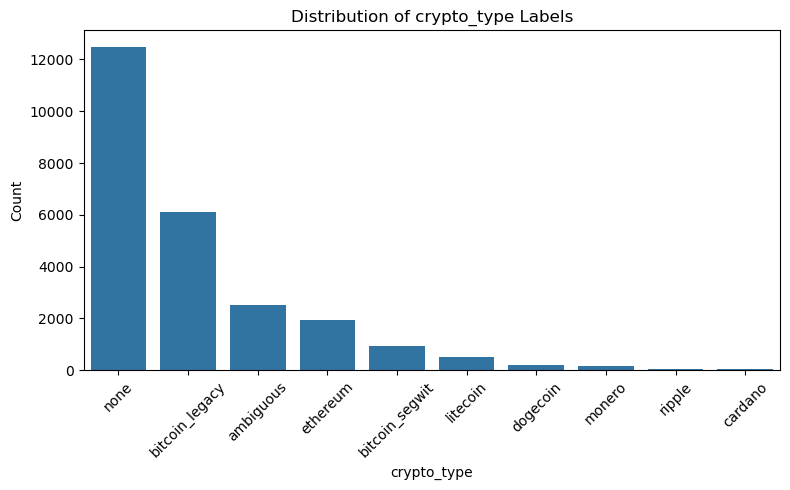

,Count,Percentage
crypto_type,,
none,12500,50.00
bitcoin_legacy,6102,24.41
ambiguous,2500,10.00
ethereum,1923,7.69
bitcoin_segwit,946,3.78
litecoin,527,2.11
dogecoin,212,0.85
monero,181,0.72
ripple,58,0.23


In [15]:
# Distribution of 'crypto_type' Labels
plt.figure(figsize=(8,5))
sns.countplot(x='crypto_type', data=df, order=df['crypto_type'].value_counts().index)
plt.title('Distribution of crypto_type Labels')
plt.xlabel('crypto_type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print table of class label distributions as percentage
label_counts = df['crypto_type'].value_counts()
label_percent = df['crypto_type'].value_counts(normalize=True) * 100
dist_table = pd.DataFrame({'Count': label_counts, 'Percentage': label_percent.round(2)})
display(dist_table)

## 5. Prepare Features and Target Variable
Select features, encode categorical variables if needed, and set 'crypto_type' as the target variable.

In [16]:
# Prepare Features and Target Variable
# Encode categorical features except target
features = df.drop('crypto_type', axis=1)
target = df['crypto_type']

# Encode categorical features if any
for col in features.select_dtypes(include=['object', 'category']).columns:
    features[col] = LabelEncoder().fit_transform(features[col])

# Encode target labels
le = LabelEncoder()
target_encoded = le.fit_transform(target)

## 6. Stratified Train-Validation Split (70-30)
Split the data into training and validation sets using stratified sampling.

In [17]:
# Stratified Train-Validation Split (70-30)
X_train, X_val, y_train, y_val = train_test_split(
    features, target_encoded, test_size=0.3, random_state=42, stratify=target_encoded)
print('Training set size:', X_train.shape)
print('Validation set size:', X_val.shape)

Training set size: (17500, 51)
Validation set size: (7500, 51)


## 7. Build Classification Pipelines
Create pipelines for SVM, Logistic Regression, Decision Tree, K-NN, Naive Bayes, MLP, and AdaBoost classifiers.

In [18]:
# Build Classification Pipelines
pipelines = {
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC())
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000))
    ]),
    'Decision Tree': Pipeline([
        ('clf', DecisionTreeClassifier())
    ]),
    'K-NN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ]),
    'Naive Bayes': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GaussianNB())
    ]),
    'MLP': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(max_iter=500))
    ]),
    'AdaBoost': Pipeline([
        ('clf', AdaBoostClassifier())
    ]),
    'Random Forest': Pipeline([
        ('clf', RandomForestClassifier())
    ])
}

## 8. Train and Evaluate Models
Train each pipeline, predict, and compute accuracy, precision, recall, f1-score, memory usage, and training time.

In [19]:
# Train and Evaluate Models
results = []
for name, pipeline in pipelines.items():
    tracemalloc.start()
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start_time
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    y_pred = pipeline.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Memory Used (KB)': peak / 1024,
        'Train Time (s)': train_time
    })

## 9. Compare Model Metrics in a Single Table
Summarize all metrics for each classification algorithm.

In [20]:
# Compare Model Metrics in a Single Table
results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,Memory Used (KB),Train Time (s)
0,SVM,0.973600,0.956176,0.973600,0.963704,21420.547852,1.832050
1,Logistic Regression,0.973600,0.956176,0.973600,0.963704,17148.481445,0.724734
2,Decision Tree,0.940533,0.949017,0.940533,0.944610,10465.956055,0.179077
3,K-NN,0.973467,0.955975,0.973467,0.963573,14892.722656,0.032338
4,Naive Bayes,0.737200,0.965821,0.737200,0.725136,14892.707031,0.045726
5,MLP,0.970133,0.956350,0.970133,0.962129,14892.691406,61.821205
6,AdaBoost,0.947600,0.931380,0.947600,0.936087,12298.357422,1.577712
7,Random Forest,0.973067,0.955679,0.973067,0.963306,10466.002930,2.808418


In [32]:
# Random Forest + Cuckoo Hashing Evaluation
# Uses variables from previous cells: features, target_encoded, X_train, X_val, y_train, y_val

# Ensure all features are numeric by encoding non-numeric columns
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# Convert X_train and X_val to DataFrames if needed
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=features.columns)
if not isinstance(X_val, pd.DataFrame):
    X_val = pd.DataFrame(X_val, columns=features.columns)

for col in X_train.columns:
    if X_train[col].dtype == 'object' or X_val[col].dtype == 'object':
        le_feat = LabelEncoder()
        vals = pd.concat([X_train[col], X_val[col]], axis=0).astype(str)
        le_feat.fit(vals)
        X_train[col] = le_feat.transform(X_train[col].astype(str))
        X_val[col] = le_feat.transform(X_val[col].astype(str))

X_train = X_train.values
X_val = X_val.values

# Cuckoo Hashing implementation
class CuckooHashTable:
    def __init__(self, size=2**18):
        self.size = size
        self.table1 = [None] * size
        self.table2 = [None] * size
    def _hash1(self, key): return hash(key) % self.size
    def _hash2(self, key): return (hash(key) // self.size) % self.size
    def insert(self, key, value):
        pos1 = self._hash1(key)
        if self.table1[pos1] is None:
            self.table1[pos1] = (key, value)
            return
        if self.table1[pos1][0] == key:
            self.table1[pos1] = (key, value)
            return
        kicked_key, kicked_value = self.table1[pos1]
        self.table1[pos1] = (key, value)
        pos2 = self._hash2(kicked_key)
        if self.table2[pos2] is None or self.table2[pos2][0] == kicked_key:
            self.table2[pos2] = (kicked_key, kicked_value)
        else:
            self.table2[pos2] = (kicked_key, kicked_value)
    def lookup(self, key):
        pos1 = self._hash1(key)
        if self.table1[pos1] and self.table1[pos1][0] == key:
            return self.table1[pos1][1]
        pos2 = self._hash2(key)
        if self.table2[pos2] and self.table2[pos2][0] == key:
            return self.table2[pos2][1]
        return None

# Store train/val data in Cuckoo Hashing
cuckoo = CuckooHashTable(size=2**18)
for i, row in enumerate(X_train):
    cuckoo.insert(f"train_{i}", row)
for i, row in enumerate(X_val):
    cuckoo.insert(f"val_{i}", row)

# Train Random Forest on X_train, y_train with ValueError handling and measure time/memory
import time
import tracemalloc

rf_cuckoo = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
tracemalloc.start()
start_time = time.time()
try:
    rf_cuckoo.fit(X_train, y_train)
    train_time = time.time() - start_time
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
except ValueError as e:
    print(f"ValueError during Random Forest training: {e}")
    import traceback; traceback.print_exc()
    rf_cuckoo = None
    train_time = None
    peak = None

if rf_cuckoo is not None:
    # Reconstruct validation set from cuckoo
    X_val_rebuilt = []
    for i in range(len(X_val)):
        row = cuckoo.lookup(f"val_{i}")
        if row is not None:
            X_val_rebuilt.append(row)
        else:
            X_val_rebuilt.append(X_val[i])
    X_val_rebuilt = np.array(X_val_rebuilt)
    if X_val_rebuilt.shape != X_val.shape:
        X_val_rebuilt = X_val

    # Predict and evaluate
    y_pred_cuckoo = rf_cuckoo.predict(X_val_rebuilt)
    results_cuckoo = {
        "Method": "Random Forest + Cuckoo Hashing",
        "Accuracy": accuracy_score(y_val, y_pred_cuckoo),
        "Precision": precision_score(y_val, y_pred_cuckoo, average="macro", zero_division=0),
        "Recall": recall_score(y_val, y_pred_cuckoo, average="macro", zero_division=0),
        "F1": f1_score(y_val, y_pred_cuckoo, average="macro", zero_division=0),
        "Memory Used (KB)": peak / 1024 if peak is not None else None,
        "Train Time (s)": train_time
    }

    # Display results
    results_df = pd.DataFrame([results_cuckoo])
    display(results_df)

,Method,Accuracy,Precision,Recall,F1,Memory Used (KB),Train Time (s)
0,Random Forest + Cuckoo Hashing,0.971067,0.639219,0.582359,0.579499,23679.72168,1.309319


In [ ]:
# Ensemble K-NN (random features + random samples) Evaluation
# Uses train-validation split data from previous cells: X_train, X_val, y_train, y_val

import numpy as np
import pandas as pd
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Parameters
n_learners = 10        # number of weak K-NN learners
feature_frac = 0.8     # fraction of features per learner
sample_frac = 0.8      # fraction of records per learner
k_neighbors = 5

learners = []
feature_indices_list = []

# Ensure y_train is a numpy array
y_train_np = np.array(y_train)

# Defensive: Ensure X_train and X_val are numpy arrays
if isinstance(X_train, pd.DataFrame):
    X_train = X_train.values
if isinstance(X_val, pd.DataFrame):
    X_val = X_val.values

# Defensive: Check shapes
if X_train.shape[0] == 0 or X_val.shape[0] == 0:
    raise ValueError("Training or validation set is empty.")

import tracemalloc
tracemalloc.start()
train_start_time = time.time()
for i in range(n_learners):
    # Random feature subset
    feat_idx = np.random.choice(X_train.shape[1], size=max(1,int(feature_frac*X_train.shape[1])), replace=False)
    feature_indices_list.append(feat_idx)
    # Random record subset
    sample_idx = np.random.choice(X_train.shape[0], size=max(1,int(sample_frac*X_train.shape[0])), replace=True)
    X_sub = np.take(np.take(X_train, sample_idx, axis=0), feat_idx, axis=1)
    y_sub = np.take(y_train_np, sample_idx)
    # Defensive: Check for constant target
    if len(np.unique(y_sub)) < 2:
        print(f"Learner {i} skipped: only one class in sample.")
        continue
    # Train KNN with error handling
    knn = KNeighborsClassifier(n_neighbors=min(k_neighbors, len(y_sub)))
    try:
        knn.fit(X_sub, y_sub)
        learners.append(knn)
    except Exception as e:
        print(f"KNN fit error for learner {i}: {e}")
        continue
train_time = time.time() - train_start_time
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Ensemble Prediction
pred_start_time = time.time()
y_pred_ensemble = []
for i in range(X_val.shape[0]):
    votes = []
    for knn, feats in zip(learners, feature_indices_list):
        try:
            x_row = np.take(X_val[i], feats).reshape(1, -1)
            pred = knn.predict(x_row)[0]
            votes.append(pred)
        except Exception as e:
            print(f"Prediction error for sample {i} in learner: {e}")
            continue
    # Majority vote
    if votes:
        y_pred_ensemble.append(pd.Series(votes).mode()[0])
    else:
        # Fallback: use most common class in y_train
        y_pred_ensemble.append(pd.Series(y_train_np).mode()[0])
predict_time = time.time() - pred_start_time

# Metrics
acc = accuracy_score(y_val, y_pred_ensemble)
prec = precision_score(y_val, y_pred_ensemble, average="macro", zero_division=0)
rec = recall_score(y_val, y_pred_ensemble, average="macro", zero_division=0)
f1 = f1_score(y_val, y_pred_ensemble, average="macro", zero_division=0)

# Summary table
results_knn_ensemble = pd.DataFrame([{
    "Method": "Ensemble K-NN (random features + random samples)",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1-Score": f1,
    "Memory Used (KB)": peak / 1024,
    "Train Time (s)": train_time,
    "Predict Time (s)": predict_time
}])

display(results_knn_ensemble)

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''